<a href="https://colab.research.google.com/github/jaydeep12b/Major-Project-II/blob/main/stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install yfinance


In [ ]:
import yfinance as yf


In [ ]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [ ]:
stock = "GOOG"
google_df = yf.download(stock, start, end)

/tmp/ipython-input-186288589.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google_df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [ ]:
google_df

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2005-11-07,9.771999,9.832359,9.700756,9.773732,385098052
2005-11-08,9.645097,9.785853,9.612444,9.752704,317084071
2005-11-09,9.379171,9.605272,9.351466,9.565197,420245300
2005-11-10,9.674782,9.680967,9.336623,9.359629,366516664
2005-11-11,9.657465,9.818258,9.619122,9.774225,283615089
...,...,...,...,...,...
2025-10-31,281.820007,286.285004,277.523010,283.204987,29932800
2025-11-03,284.119995,285.940002,280.369995,282.420013,19691800


In [ ]:
google_df.shape

(5032, 5)

In [ ]:
google_df.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5032.000000,5032.000000,5032.000000,5032.000000,5.032000e+03
mean,56.414072,56.994118,55.807192,56.382427,9.149481e+07
std,54.500598,55.081759,53.878312,54.443164,1.151071e+08
min,6.368385,6.663503,6.117549,6.493804,1.584340e+05
25%,14.286320,14.395906,14.151872,14.260779,2.537455e+07
50%,33.973261,34.627037,33.792001,34.152535,4.268644e+07
75%,83.589222,85.988803,82.783363,84.640825,1.132660e+08
max,285.339996,291.929993,281.619995,291.720001,1.650833e+09


In [ ]:
google_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5032 entries, 2005-11-07 to 2025-11-06
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5032 non-null   float64
 1   (High, GOOG)    5032 non-null   float64
 2   (Low, GOOG)     5032 non-null   float64
 3   (Open, GOOG)    5032 non-null   float64
 4   (Volume, GOOG)  5032 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.9 KB


In [ ]:
google_df.isna().sum()

,,0
Price,Ticker,
Close,GOOG,0
High,GOOG,0
Low,GOOG,0
Open,GOOG,0
Volume,GOOG,0


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")

In [ ]:
google_df.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

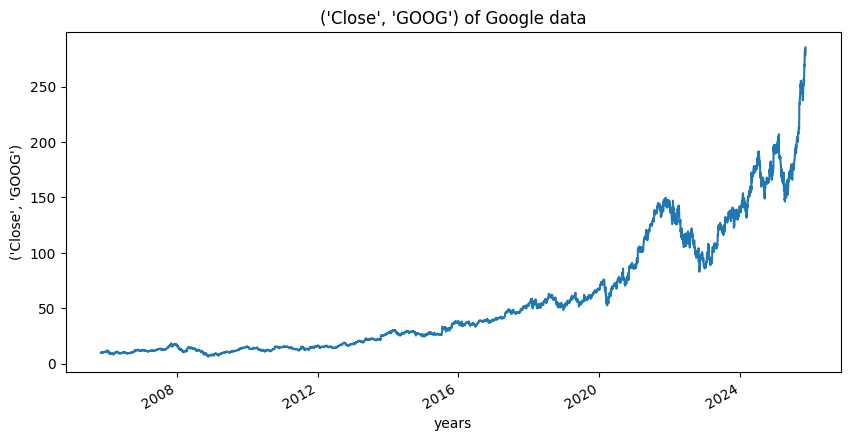

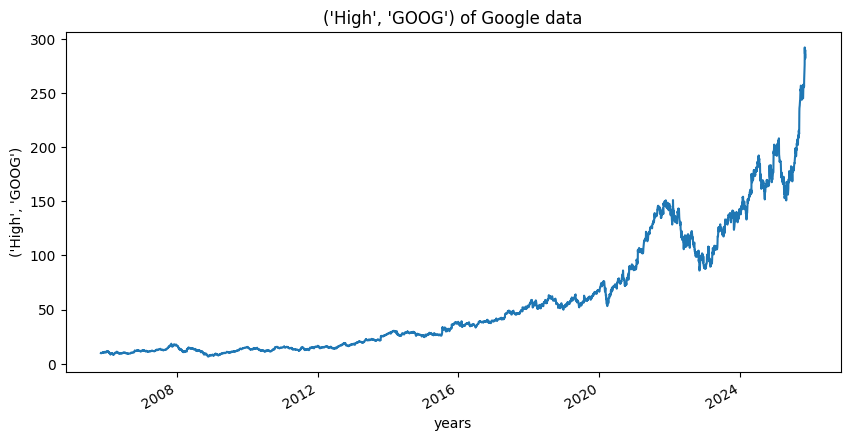

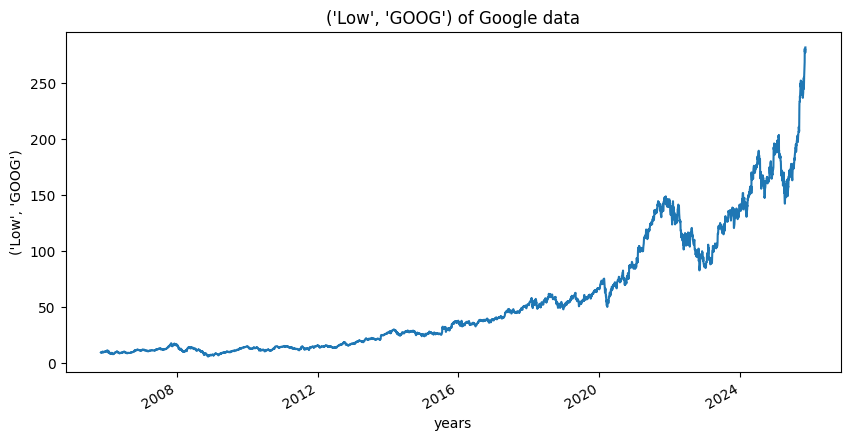

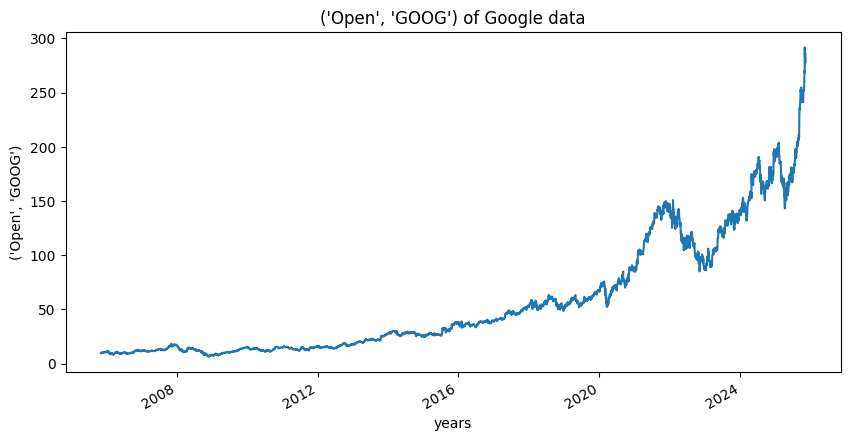

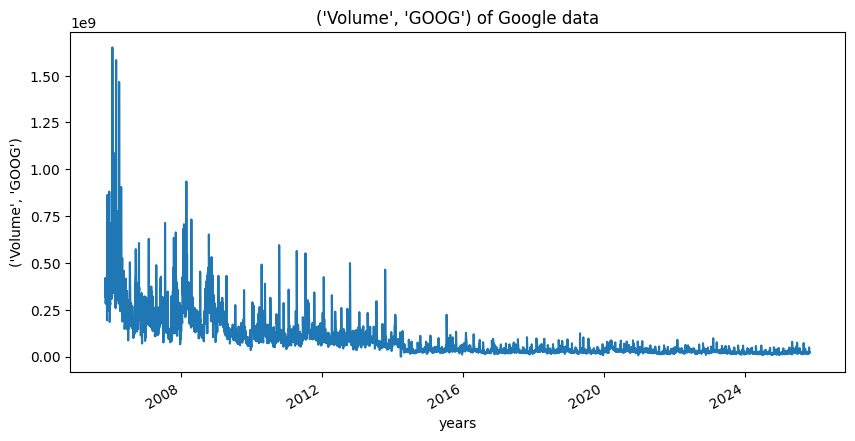

In [ ]:
for column_name in google_df.columns:
  plot_graph((10,5), google_df[column_name], column_name)

In [ ]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [ ]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [ ]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [ ]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [ ]:
for i in range(2004,2025):
    print(i,list(google_df.index.year).count(i))

2004 0
2005 38
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252


In [ ]:
google_df['MA_for_250_days'] = google_df['Close'].rolling(250).mean()


In [ ]:
google_df['MA_for_250_days'][0:250].tail()

,MA_for_250_days
Date,
2006-10-27,NaN
2006-10-30,NaN
2006-10-31,NaN
2006-11-01,NaN
2006-11-02,9.906926


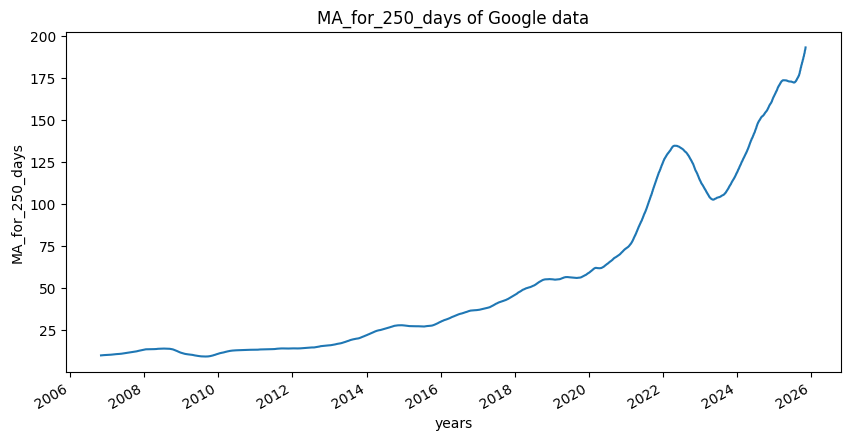

In [ ]:
plot_graph((10,5), google_df['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

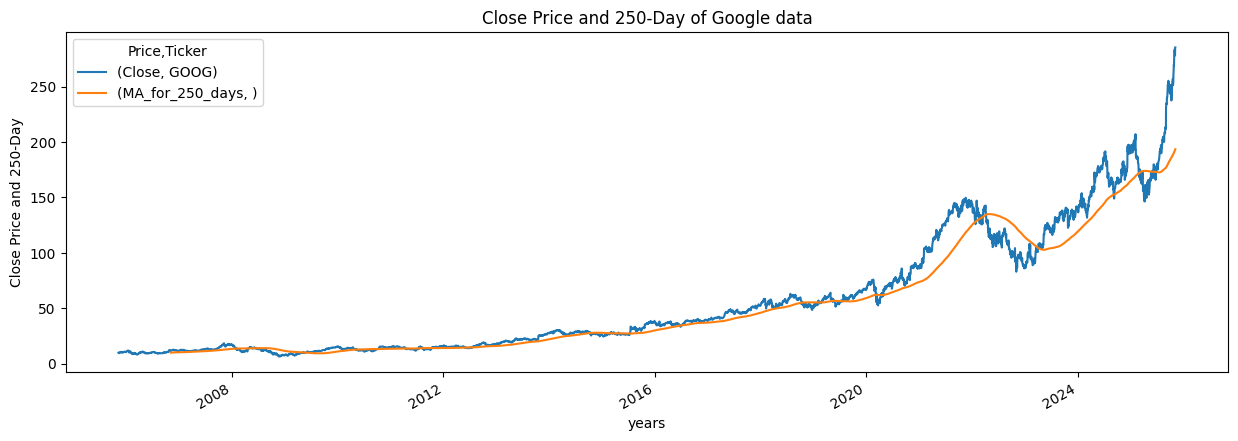

In [ ]:
plot_graph((15,5), google_df[['Close','MA_for_250_days']], 'Close Price and 250-Day')

<Figure size 640x480 with 0 Axes>

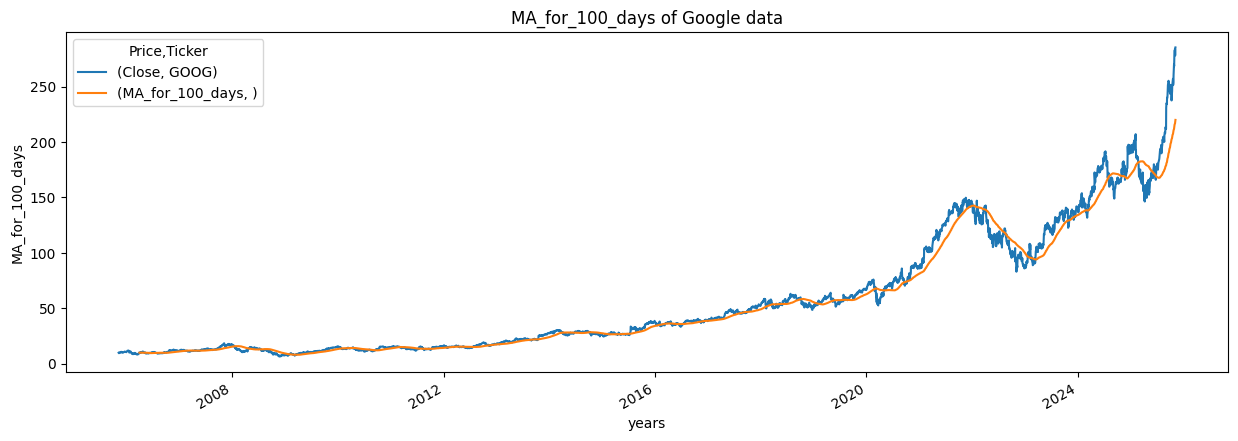

In [ ]:
google_df['MA_for_100_days'] = google_df['Close'].rolling(100).mean()
plot_graph((15,5), google_df[['Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

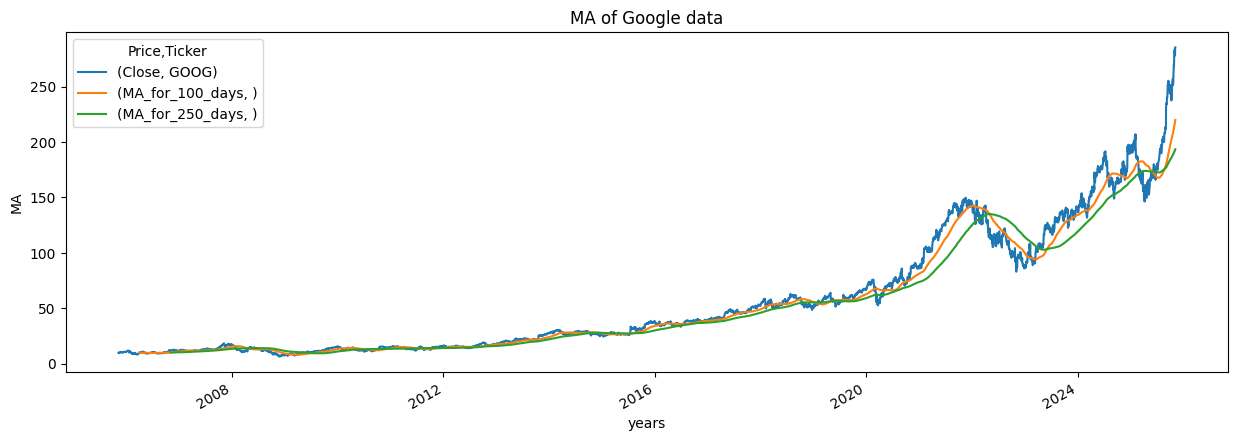

In [ ]:
plot_graph((15,5), google_df[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')

In [ ]:
google_df['percentage_change_cp'] = google_df['Close'].pct_change()
google_df[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,GOOG,
Date,,
2005-11-07,9.771999,NaN
2005-11-08,9.645097,-0.012986
2005-11-09,9.379171,-0.027571
2005-11-10,9.674782,0.031518
2005-11-11,9.657465,-0.001790


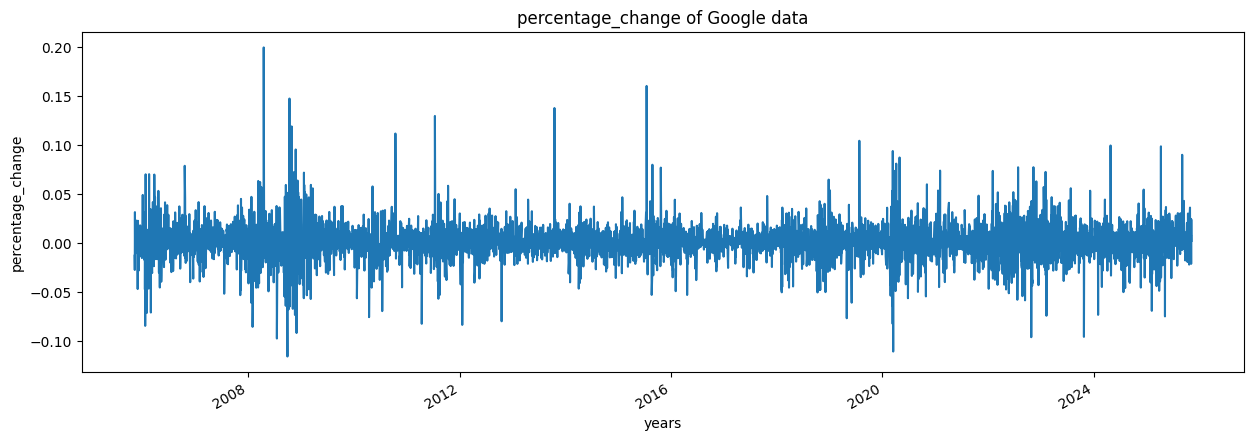

In [ ]:
plot_graph((15,5), google_df['percentage_change_cp'], 'percentage_change')

In [ ]:
close_price = google_df[['Close']]

In [ ]:
max(close_price.values),min(close_price.values)

(array([285.33999634]), array([6.36838531]))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_price)
scaled_data

array([[0.01220057],
       [0.01174568],
       [0.01079245],
       ...,
       [0.97390416],
       [0.9978851 ],
       [1.        ]])

In [ ]:
len(scaled_data)

5032

In [ ]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [ ]:
x_data[0],y_data[0]

(array([[0.01220057],
        [0.01174568],
        [0.01079245],
        [0.01185209],
        [0.01179002],
        [0.0123726 ],
        [0.01200283],
        [0.01247723],
        [0.0129472 ],
        [0.0126599 ],
        [0.01347127],
        [0.01410174],
        [0.01466835],
        [0.01517911],
        [0.01472333],
        [0.01295518],
        [0.01307667],
        [0.01389069],
        [0.0142108 ],
        [0.01316002],
        [0.01304386],
        [0.01301549],
        [0.01358565],
        [0.01345708],
        [0.01375945],
        [0.01419218],
        [0.01432253],
        [0.01464087],
        [0.01531478],
        [0.01482265],
        [0.01527843],
        [0.01497606],
        [0.01548238],
        [0.01538395],
        [0.01482619],
        [0.01500797],
        [0.01442805],
        [0.01395897],
        [0.01576525],
        [0.01665287],
        [0.0171849 ],
        [0.01846358],
        [0.01857353],
        [0.01882714],
        [0.01899296],
        [0

In [ ]:
int(len(x_data)*0.7)

3452

In [ ]:
4908-100-int(len(x_data)*0.7)

1356

In [ ]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3452, 100, 1)
(3452, 1)
(1480, 100, 1)
(1480, 1)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [ ]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 266s 76ms/step - loss: 1.5415e-04
Epoch 2/2
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 262s 76ms/step - loss: 2.8380e-05


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [ ]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step


In [ ]:
predictions

array([[0.2117903 ],
       [0.21148284],
       [0.21161394],
       ...,
       [0.95618564],
       [0.94459796],
       [0.95152533]], dtype=float32)

In [ ]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 65.451866],
       [ 65.36609 ],
       [ 65.402664],
       ...,
       [273.11703 ],
       [269.8844  ],
       [271.81696 ]], dtype=float32)

In [ ]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 67.17133331],
       [ 67.34116364],
       [ 67.02085876],
       ...,
       [278.05999756],
       [284.75      ],
       [285.33999634]])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate MSE
mse = mean_squared_error(inv_y_test, inv_predictions)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R² Score
r2 = r2_score(inv_y_test, inv_predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"R² Score (Model Accuracy): {r2}")

Mean Squared Error (MSE): 23.091531858431463
Root Mean Square Error (RMSE): 4.8053649037748905
R² Score (Model Accuracy): 0.9873192793771064


In [ ]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_df.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2019-12-18,67.171333,65.451866
2019-12-19,67.341164,65.366089
2019-12-20,67.020859,65.402664
2019-12-23,66.983620,65.269524
2019-12-24,66.721413,65.175217


<Figure size 640x480 with 0 Axes>

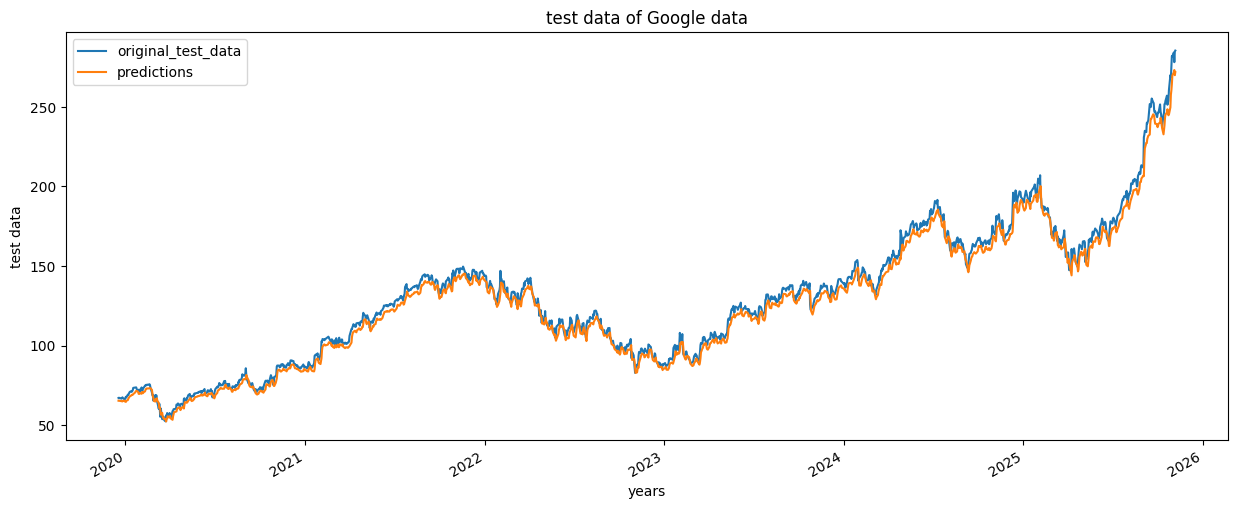

In [ ]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

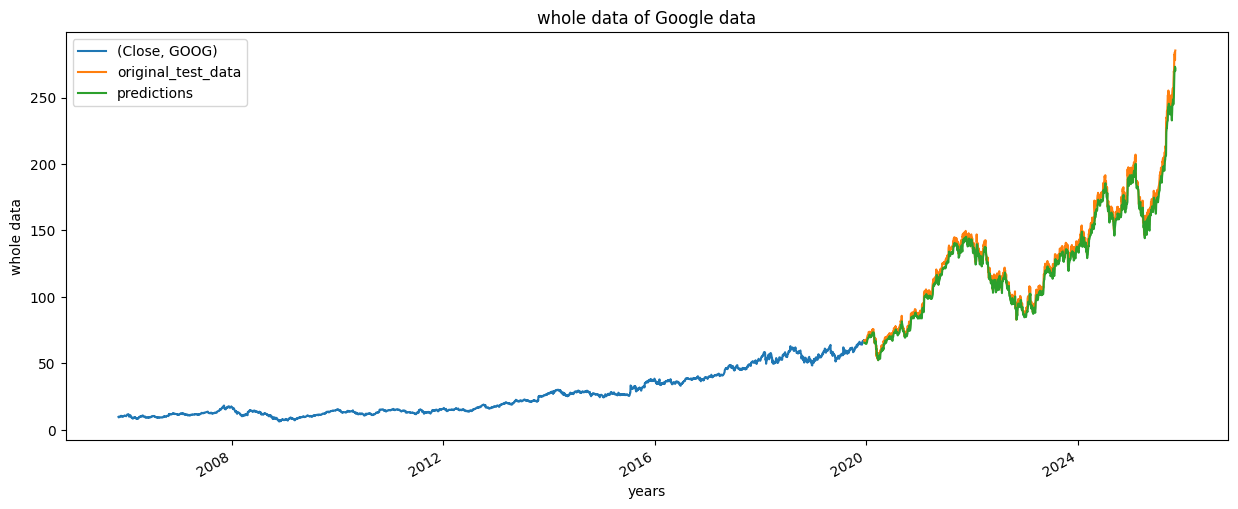

In [ ]:
plot_graph((15,6), pd.concat([close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')


In [ ]:
model.save("Latest_stock_price_model.keras")